In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [2]:
import pandas as pd
import glob
import os
from pathlib import Path
from pandas.errors import EmptyDataError

def load_csv_folder_with_event_offset(folder, event_col="event_id", verbose=True):
    """
    Recursively loads ALL CSVs inside `folder` and subfolders.
    Applies a running offset to event_id so events remain unique across files.
    Skips empty or invalid CSV files safely.
    """

    pattern = os.path.join(folder, "**", "*.csv")
    csv_files = glob.glob(pattern, recursive=True)

    if len(csv_files) == 0:
        raise RuntimeError(f"No CSV files found anywhere under {folder}")

    csv_files = sorted(csv_files, key=lambda p: Path(p).as_posix())

    if verbose:
        print(f"Found {len(csv_files)} csv files")

    dfs = []
    event_offset = 0
    total_events = 0
    skipped_files = 0

    for i, f in enumerate(csv_files):

        if verbose and (i % 20 == 0):
            print(f"[{i+1}/{len(csv_files)}] Loading: {f}")

        if os.path.getsize(f) == 0:
            if verbose:
                print(f"  -> Skipping empty file (0 bytes)")
            skipped_files += 1
            continue

        try:
            df = pd.read_csv(f)
        except EmptyDataError:
            if verbose:
                print(f"  -> Skipping: no data inside CSV")
            skipped_files += 1
            continue
        except Exception as e:
            if verbose:
                print(f"  -> Skipping malformed CSV: {e}")
            skipped_files += 1
            continue

        if df.shape[0] == 0:
            if verbose:
                print(f"  -> Skipping: CSV has 0 rows")
            skipped_files += 1
            continue

        if event_col not in df.columns:
            if verbose:
                print(f"  -> Skipping: {event_col} not found")
            skipped_files += 1
            continue

        n_events = df[event_col].nunique()

        if n_events == 0:
            if verbose:
                print(f"  -> Skipping: no unique events")
            skipped_files += 1
            continue

        df[event_col] += event_offset

        dfs.append(df)

        event_offset += n_events
        total_events += n_events

    if len(dfs) == 0:
        raise RuntimeError("All CSV files were empty or invalid.")

    if verbose:
        print(f"\nTotal unique events loaded: {total_events}")
        print(f"Final event_id range: 0 → {event_offset-1}")
        print(f"Skipped files: {skipped_files}")

    return pd.concat(dfs, ignore_index=True)

In [3]:
df_contrastive_em = load_csv_folder_with_event_offset("../Emb_Em/cont_sep/")
df_oc_em          = load_csv_folder_with_event_offset("../Emb_Em/oc_sep")
df_contrastive_had = load_csv_folder_with_event_offset("../Emb_pion/cont_sep")
df_oc_had          = load_csv_folder_with_event_offset("../Emb_pion/oc_sep/")

print(df_contrastive["event_id"].min(), df_contrastive["event_id"].max())
print(df_oc["event_id"].min(), df_oc["event_id"].max())



Found 4000 csv files
[1/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1001_1002.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[21/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1039_1040.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[41/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1075_1076.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[61/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1111_1112.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[81/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1147_1148.csv
  -> Skipping: no data inside CSV
[101/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1183_1184.csv
  -> Skipping: no data inside CSV
[121/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1219_1220.csv
[141/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1255_1256.csv
[161/4000] Loading: ../Emb_Em/cont_sep/Test_pi.1291_1292.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data insid

  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1521/4000] Loading: ../Emb_Em/cont_sep/Test_pi.373_374.csv
  -> Skipping: no data inside CSV
[1541/4000] Loading: ../Emb_Em/cont_sep/Test_pi.3777_3778.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1561/4000] Loading: ../Emb_Em/cont_sep/Test_pi.3811_3812.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1581/4000] Loading: ../Emb_Em/cont_sep/Test_pi.3847_3848.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1601/4000] Loading: ../Emb_Em/cont_sep/Test_pi.3883_3884.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1621/4000] Loading: ../Emb_Em/cont_sep/Test_pi.391_392.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1641/4000] Loading:

  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2941/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6295_6296.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2961/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6331_6332.csv
  -> Skipping: no data inside CSV
[2981/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6367_6368.csv
  -> Skipping: no data inside CSV
[3001/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6401_6402.csv
  -> Skipping: no data inside CSV
[3021/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6439_6440.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[3041/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6475_6476.csv
[3061/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6511_6512.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[3081/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6547_6548.csv
  -> Skipping: no data inside CSV
[3101/4000] Loading: ../Emb_Em/cont_sep/Test_pi.6583_6584.csv


[461/4000] Loading: ../Emb_Em/oc_sep/Test_pi.1831_1832.csv
  -> Skipping: no data inside CSV
[481/4000] Loading: ../Emb_Em/oc_sep/Test_pi.1867_1868.csv
  -> Skipping: no data inside CSV
[501/4000] Loading: ../Emb_Em/oc_sep/Test_pi.1903_1904.csv
  -> Skipping: no data inside CSV
[521/4000] Loading: ../Emb_Em/oc_sep/Test_pi.193_194.csv
  -> Skipping: no data inside CSV
[541/4000] Loading: ../Emb_Em/oc_sep/Test_pi.1977_1978.csv
  -> Skipping: no data inside CSV
[561/4000] Loading: ../Emb_Em/oc_sep/Test_pi.2009_2010.csv
  -> Skipping: no data inside CSV
[581/4000] Loading: ../Emb_Em/oc_sep/Test_pi.2045_2046.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[601/4000] Loading: ../Emb_Em/oc_sep/Test_pi.2081_2082.csv
[621/4000] Loading: ../Emb_Em/oc_sep/Test_pi.2119_2120.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[641/4000] Loading: ../Emb_Em/oc_sep/Test_pi.2155_2156.csv
[661

  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1881/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4387_4388.csv
  -> Skipping: no data inside CSV
[1901/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4421_4422.csv
[1921/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4459_4460.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1941/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4495_4496.csv
  -> Skipping: no data inside CSV
[1961/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4531_4532.csv
[1981/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4567_4568.csv
[2001/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4601_4602.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2021/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4639_4640.csv
[2041/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4675_4676.csv
  -> Skipping: no data inside CSV
[2061/4000] Loading: ../Emb_Em/oc_sep/Test_pi.4711_4712.csv
  -> Skipping: no data inside CSV
[2081/4000] Loading: ../Em

...

  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2361/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5251_5252.csv
[2381/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5287_5288.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2401/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5323_5324.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2421/4000] Loading: ../Emb_pion/cont_sep/Test_pi.535_536.csv
  -> Skipping: no data inside CSV
[2441/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5397_5398.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2461/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5431_5432.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2481/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5467_5468.csv
[2501/4000] Loading: ../Emb_pion/cont_sep/Test_pi.5503_5504.csv
  -> Skipping:

  -> Skipping: no data inside CSV
[3781/4000] Loading: ../Emb_pion/cont_sep/Test_pi.7807_7808.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[3801/4000] Loading: ../Emb_pion/cont_sep/Test_pi.7843_7844.csv
[3821/4000] Loading: ../Emb_pion/cont_sep/Test_pi.787_788.csv
  -> Skipping: no data inside CSV
[3841/4000] Loading: ../Emb_pion/cont_sep/Test_pi.7917_7918.csv
[3861/4000] Loading: ../Emb_pion/cont_sep/Test_pi.7953_7954.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[3881/4000] Loading: ../Emb_pion/cont_sep/Test_pi.7989_7990.csv
[3901/4000] Loading: ../Emb_pion/cont_sep/Test_pi.821_822.csv
  -> Skipping: no data inside CSV
[3921/4000] Loading: ../Emb_pion/cont_sep/Test_pi.859_860.csv
[3941/4000] Loading: ../Emb_pion/cont_sep/Test_pi.895_896.csv
  -> Skipping: no data inside CSV
[3961/4000] Loading: ../Emb_pion/cont_sep/Test_pi.931_932.csv
[3981/4000] Loading: ../Emb_pion/cont_sep/Test_pi.967_968.csv

Total unique events loaded: 9949
Fi

[1361/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3451_3452.csv
  -> Skipping: no data inside CSV
[1381/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3487_3488.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1401/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3523_3524.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1421/4000] Loading: ../Emb_pion/oc_sep/Test_pi.355_356.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1441/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3597_3598.csv
  -> Skipping: no data inside CSV
[1461/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3631_3632.csv
  -> Skipping: no data inside CSV
[1481/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3667_3668.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[1501/4000] Loading: ../Emb_pion/oc_sep/Test_pi.3703_3704.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside 

  -> Skipping: no data inside CSV
[2761/4000] Loading: ../Emb_pion/oc_sep/Test_pi.5973_5974.csv
  -> Skipping: no data inside CSV
[2781/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6005_6006.csv
  -> Skipping: no data inside CSV
[2801/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6041_6042.csv
  -> Skipping: no data inside CSV
[2821/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6079_6080.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2841/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6115_6116.csv
  -> Skipping: no data inside CSV
[2861/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6151_6152.csv
[2881/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6187_6188.csv
  -> Skipping: no data inside CSV
[2901/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6221_6222.csv
  -> Skipping: no data inside CSV
  -> Skipping: no data inside CSV
[2921/4000] Loading: ../Emb_pion/oc_sep/Test_pi.6259_6260.csv


NameError: name 'df_contrastive' is not defined

In [6]:
df_contrastive_em

,n_nodes_all,n_groups_all,n_nodes,n_groups,r_at_1,r_at_5,r_at_10,auc,intra_compactness,inter_separation,intra_q99,inter_q01,knn_contam_at_10,knn_contam_at_100,event_id
0,14623,15,6004,15,0.744837,0.912059,0.947535,0.966423,0.020906,0.532725,0.405463,0.017771,0.287125,0.287653,0
1,27935,30,11926,30,0.722455,0.890659,0.925709,0.967340,0.023758,0.502759,0.471745,0.032390,0.309823,0.313043,1
2,26864,30,11457,30,0.714847,0.886445,0.920223,0.965747,0.022966,0.511711,0.469750,0.025367,0.326786,0.341278,2
3,17129,15,7171,15,0.802259,0.931669,0.955236,0.977667,0.019043,0.532181,0.439855,0.029309,0.209802,0.205647,3
4,25400,30,10811,30,0.730830,0.894367,0.929054,0.965372,0.026730,0.507656,0.482004,0.030297,0.317618,0.328089,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,3650,2,1455,2,0.991753,0.995876,0.996564,0.996777,0.015843,0.578062,0.227086,0.147955,0.009225,0.007892,9944
9945,15787,15,6520,15,0.783282,0.919632,0.944018,0.960380,0.021771,0.470916,0.451501,0.021307,0.254768,0.253755,9945
9946,3148,2,1264,2,0.905063,0.969937,0.981804,0.939260,0.018821,0.254136,0.286092,0.010045,0.090254,0.083378,9946
9947,12090,15,5476,15,0.838386,0.936267,0.956903,0.973970,0.014981,0.514760,0.457807,0.029281,0.201434,0.200548,9947


In [4]:
import numpy as np
import pandas as pd

METRICS = [
    "r_at_1", "r_at_10",
    "auc",
    "intra_compactness", "intra_q99", "inter_separation", "inter_q01",
    "knn_contam_at_10", 
]

def metric_mean_std_table(df, model_name, group_values, metrics=METRICS):
    """
    group_values: iterable of n_groups values to include as rows (e.g. [2,3,...,10] or [2,10])
    Returns long-form table with mean/std/count per (model, n_groups, metric).
    """
    rows = []
    for g in group_values:
        sub = df[df["n_groups"] == g]
        n = len(sub)
        for m in metrics:
            x = sub[m].to_numpy()
            x = x[np.isfinite(x)]
            rows.append({
                "model": model_name,
                "n_groups": int(g),
                "metric": m,
                "mean": float(np.mean(x)) if x.size else np.nan,
                "std": float(np.std(x, ddof=1)) if x.size > 1 else np.nan,
                "n_events": int(n),
            })
    return pd.DataFrame(rows)

def wide_mean_std_table(df_contrastive, df_oc, group_values, metrics=METRICS):
    """
    Returns a wide table with one row per (n_groups, metric) and columns:
      Contrastive_mean, Contrastive_std, OC_mean, OC_std, n_events_Contrastive, n_events_OC
    """
    t1 = metric_mean_std_table(df_contrastive, "Contrastive", group_values, metrics)
    t2 = metric_mean_std_table(df_oc, "OC", group_values, metrics)
    t = pd.concat([t1, t2], ignore_index=True)

    # pivot to wide
    wide = t.pivot_table(
        index=["n_groups", "metric"],
        columns="model",
        values=["mean", "std", "n_events"],
        aggfunc="first"
    )

    # flatten columns
    wide.columns = [f"{model}_{stat}" for stat, model in wide.columns]
    wide = wide.reset_index()

    # optional: nicer ordering
    wide["metric"] = pd.Categorical(wide["metric"], categories=metrics, ordered=True)
    wide = wide.sort_values(["n_groups", "metric"]).reset_index(drop=True)
    return wide

# --------- usage A: exactly n_groups=2 and n_groups=10 ----------
table_2_10 = wide_mean_std_table(df_contrastive_had, df_oc_had, group_values=[2, 15, 30])
table_2_10

,n_groups,metric,Contrastive_mean,OC_mean,Contrastive_n_events,OC_n_events,Contrastive_std,OC_std
0,2,r_at_1,0.947822,0.935746,3321,3321,0.044052,0.051278
1,2,r_at_10,0.992221,0.989868,3321,3321,0.004538,0.004970
2,2,auc,0.954709,0.940758,3321,3321,0.061631,0.069466
3,2,intra_compactness,0.018187,0.012290,3321,3321,0.008065,0.012107
4,2,intra_q99,0.297714,0.657088,3321,3321,0.062766,0.165616
5,2,inter_separation,0.352362,0.638756,3321,3321,0.100629,0.198518
6,2,inter_q01,0.028061,0.013642,3321,3321,0.029438,0.034360
7,2,knn_contam_at_10,0.065250,0.076304,3321,3321,0.052489,0.059455
8,15,r_at_1,0.713790,0.672521,3339,3339,0.038222,0.040838
9,15,r_at_10,0.928888,0.912796,3339,3339,0.009964,0.011418


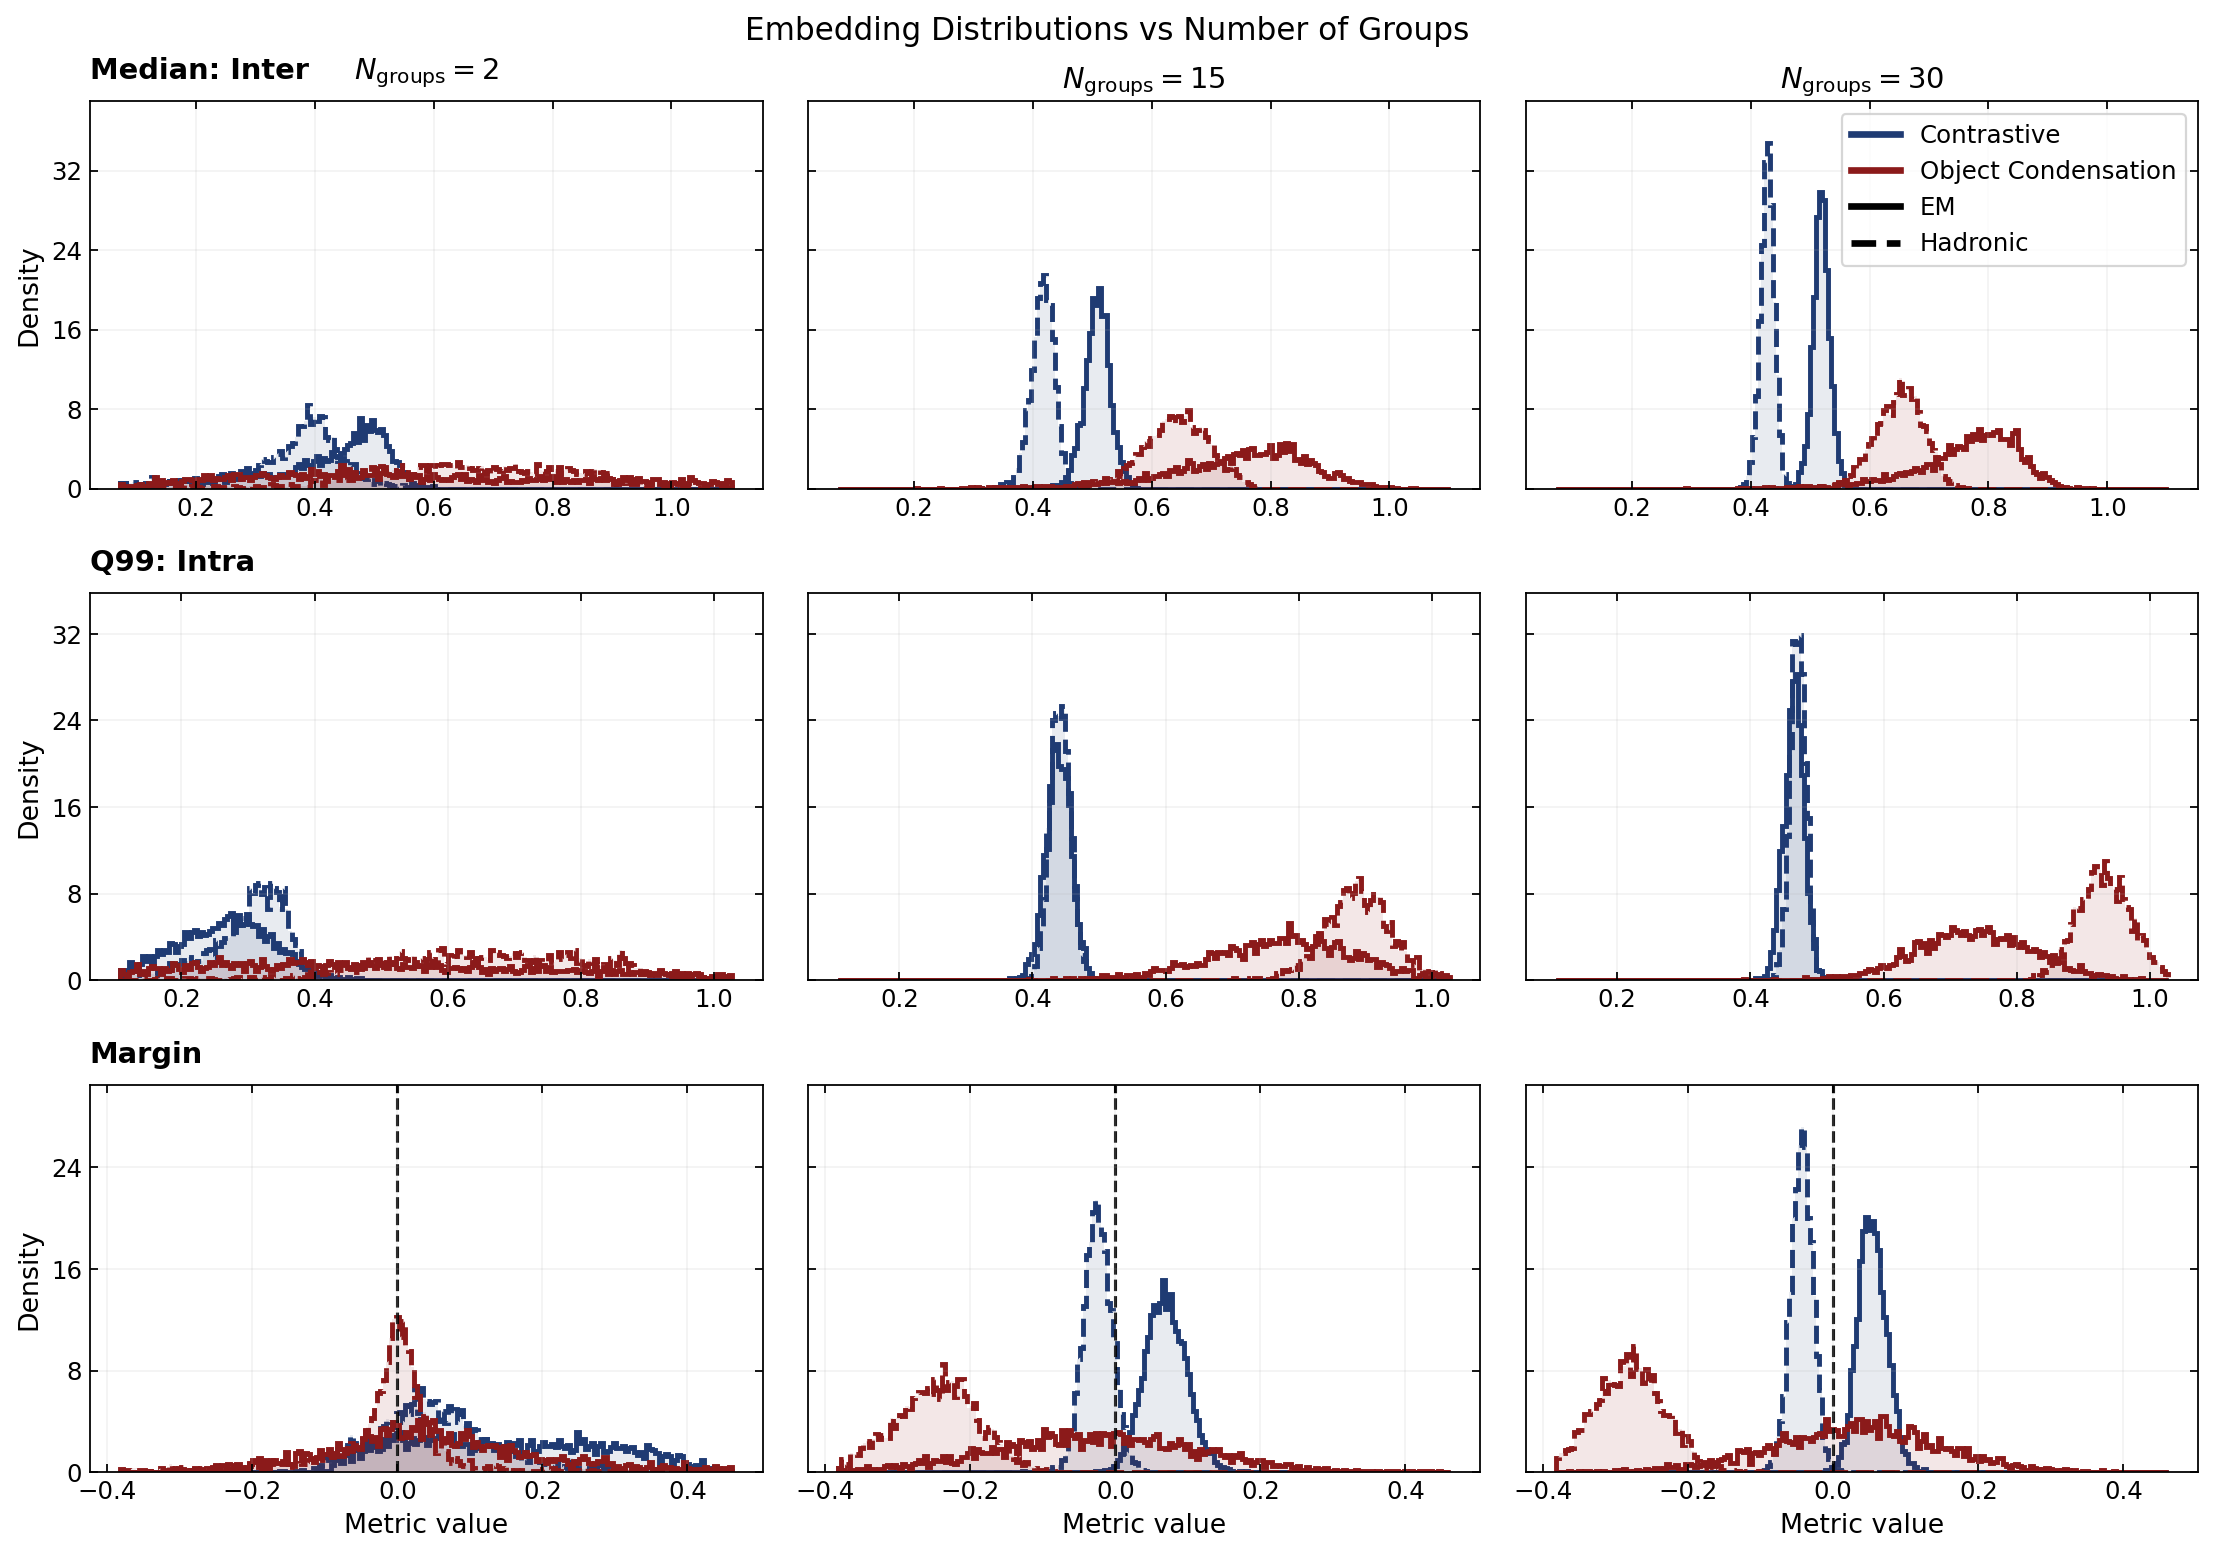

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

def plot_three_hist_panels_4curves(
    df_contrastive_em,
    df_contrastive_had,
    df_oc_em,
    df_oc_had,
    *,
    group_values=(2, 15, 30),
    intra_col="intra_q99",
    inter_col="inter_separation",
    bins=200,
    density=True,
    clip_percentiles=(0.5, 99.5),
    figsize=(14, 10),
    dpi=160,
    lw=2.2,
    alpha_fill=0.10,  
    savepath="Embedding.pdf",
):

    BLUE_DARK  = "#1f3b73"
    RED_DARK   = "#8b1a1a"

    group_values = list(group_values)
    n = len(group_values)

    def _clean_vals(df, g, col):
        v = df.loc[df["n_groups"] == g, col].to_numpy(dtype=float, copy=False)
        v = v[np.isfinite(v)]
        return v

    def _clean_margin(df, g, intra_c, inter_c):
        # margin := inter - intra (positive = easier clustering)
        sub = df.loc[df["n_groups"] == g, [intra_c, inter_c]].to_numpy(dtype=float, copy=False)
        if sub.size == 0:
            return np.array([], dtype=float)
        intra = sub[:, 0]
        inter = sub[:, 1]
        m = np.isfinite(intra) & np.isfinite(inter)
        return (inter[m] - intra[m]).astype(float, copy=False)


    data = {
        "inter":  {"C_em": {}, "C_had": {}, "O_em": {}, "O_had": {}},
        "intra":  {"C_em": {}, "C_had": {}, "O_em": {}, "O_had": {}},
        "margin": {"C_em": {}, "C_had": {}, "O_em": {}, "O_had": {}},
    }

    for g in group_values:
        data["inter"]["C_em"][g]  = _clean_vals(df_contrastive_em,  g, inter_col)
        data["inter"]["C_had"][g] = _clean_vals(df_contrastive_had, g, inter_col)
        data["inter"]["O_em"][g]  = _clean_vals(df_oc_em,           g, inter_col)
        data["inter"]["O_had"][g] = _clean_vals(df_oc_had,          g, inter_col)

        data["intra"]["C_em"][g]  = _clean_vals(df_contrastive_em,  g, intra_col)
        data["intra"]["C_had"][g] = _clean_vals(df_contrastive_had, g, intra_col)
        data["intra"]["O_em"][g]  = _clean_vals(df_oc_em,           g, intra_col)
        data["intra"]["O_had"][g] = _clean_vals(df_oc_had,          g, intra_col)

        data["margin"]["C_em"][g]  = _clean_margin(df_contrastive_em,  g, intra_col, inter_col)
        data["margin"]["C_had"][g] = _clean_margin(df_contrastive_had, g, intra_col, inter_col)
        data["margin"]["O_em"][g]  = _clean_margin(df_oc_em,           g, intra_col, inter_col)
        data["margin"]["O_had"][g] = _clean_margin(df_oc_had,          g, intra_col, inter_col)


    def _row_bin_edges(key):
        allv = []
        for g in group_values:
            for tag in ("C_em", "C_had", "O_em", "O_had"):
                allv.append(data[key][tag][g])
        if not any(v.size > 0 for v in allv):
            return None

        allv = np.concatenate([v for v in allv if v.size > 0])
        allv = allv[np.isfinite(allv)]
        if allv.size == 0:
            return None

        lo, hi = np.percentile(allv, clip_percentiles)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo = float(np.nanmin(allv))
            hi = float(np.nanmax(allv))
            if lo == hi:
                lo -= 1.0
                hi += 1.0

        return np.linspace(lo, hi, bins + 1)

    bin_edges_inter  = _row_bin_edges("inter")
    bin_edges_intra  = _row_bin_edges("intra")
    bin_edges_margin = _row_bin_edges("margin")

    if bin_edges_inter is None and bin_edges_intra is None and bin_edges_margin is None:
        print("No valid values found for any row.")
        return


    fig, axes = plt.subplots(
        3, n,
        figsize=figsize,
        dpi=dpi,
        sharex="row",
        sharey="row",
    )
    if n == 1:
        axes = axes.reshape(3, 1)

    styles = [
        ("C_em",  BLUE_DARK, "-",  "Contrastive"),
        ("C_had", BLUE_DARK, "--", "Contrastive"),
        ("O_em",  RED_DARK,  "-",  "Object Condensation"),
        ("O_had", RED_DARK,  "--", "Object Condensation"),
    ]

    def _setup_axis(ax):
        # closed box
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        # clean ticks/grid
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.grid(True, alpha=0.15, linewidth=0.8)
        ax.tick_params(direction="in", top=True, right=True)

    def _histline(ax, values, edges, *, color, ls):
        if values.size == 0 or edges is None:
            return 0.0
        counts, _ = np.histogram(values, bins=edges, density=density)

        if alpha_fill and alpha_fill > 0:
            ax.stairs(counts, edges, fill=True, linewidth=0.0, edgecolor="none",
                      facecolor=color, alpha=alpha_fill)

        ax.stairs(counts, edges, color=color, linestyle=ls, linewidth=lw)
        return float(np.nanmax(counts)) if counts.size else 0.0

    def _panel_title(g):
        return rf"$N_\mathrm{{groups}}={g}$"

    def _plot_row(row_idx, key, bin_edges, short_row_label):
        if bin_edges is None:
            for j in range(n):
                ax = axes[row_idx, j]
                ax.text(0.5, 0.5, "No valid values", ha="center", va="center", transform=ax.transAxes)
                _setup_axis(ax)
            axes[row_idx, 0].set_ylabel("Density" if density else "Counts")
            axes[row_idx, 0].set_title(short_row_label, loc="left", pad=10, fontweight="bold")
            return

        max_y = 0.0
        for j, g in enumerate(group_values):
            ax = axes[row_idx, j]
            for tag, color, ls, _ in styles:
                v = data[key][tag][g]
                max_y = max(max_y, _histline(ax, v, bin_edges, color=color, ls=ls))

            if row_idx == 0:
                ax.set_title(_panel_title(g))
            _setup_axis(ax)

        for j in range(n):
            axes[row_idx, j].set_ylim(0, max_y * 1.12 if max_y > 0 else 1.0)

        # short row label on the left, like a mini header
        axes[row_idx, 0].set_title(short_row_label, loc="left", pad=10, fontweight="bold")
        axes[row_idx, 0].set_ylabel("Density" if density else "Counts")

    _plot_row(0, "inter",  bin_edges_inter,  "Median: Inter")
    _plot_row(1, "intra",  bin_edges_intra,  "Q99: Intra")
    _plot_row(2, "margin", bin_edges_margin, "Margin")

    for j in range(n):
        axes[2, j].set_xlabel("Metric value")

    for j in range(n):
        axes[2, j].axvline(0.0, color="black", linestyle="--", linewidth=1.4, alpha=0.9, zorder=1)

    legend_elements = [
        Line2D([0], [0], color=BLUE_DARK, lw=3, linestyle="-",  label="Contrastive"),
        Line2D([0], [0], color=RED_DARK,  lw=3, linestyle="-",  label="Object Condensation"),
        Line2D([0], [0], color="black",   lw=3, linestyle="-",  label="EM"),
        Line2D([0], [0], color="black",   lw=3, linestyle="--", label="Hadronic"),
    ]
    axes[0, -1].legend(handles=legend_elements, loc="upper right", frameon=True)

    fig.suptitle(
        "Embedding Distributions vs Number of Groups",
        fontsize=14,
        y=0.97,
    )



    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()


# Example usage:
plot_three_hist_panels_4curves(df_contrastive_em, df_contrastive_had, df_oc_em, df_oc_had)